# 03 — Financial Analysis

**Objective:** Turn the verified 2017–2025 series into the controller-relevant analytics that explain how Interfood actually performs — profitability, growth drivers, working-capital intensity, cash conversion, and balance-sheet health — and interpret each in the context of a commodity-trading business.

**Inputs:**
- `../data/interfood.db` (built in notebook 02)

**Expected output:**
- A set of computed ratios, trend tables, and annotated charts, plus a written summary of the key findings (which doubles as an interview-ready read of the business).

**Framing:** Interfood is a high-volume, thin-margin, capital-intensive dairy trader. Every analysis below is chosen because it speaks to one of those three characteristics — margin protection, capital efficiency, or the cash dynamics that follow from both.

## Setup — load from the database into a wide analytical view

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

data_dir = Path("../data")
charts_dir = Path("../outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(data_dir / "interfood.db")
df_long = pd.read_sql_query("SELECT * FROM summary_series", conn)
conn.close()

# Wide view: index = year, columns = metric (raw stored units: EUR '000, ratios, etc.)
wide = df_long.pivot(index="year", columns="metric", values="value").sort_index()

def m(metric):
    """Return an EUR metric in millions."""
    return wide[metric] / 1000.0

print(f"Loaded {wide.shape[0]} years x {wide.shape[1]} metrics")
wide[["sales", "gross_operating_income", "net_result", "net_working_capital"]].div(1000).round(0)

Loaded 9 years x 17 metrics


metric,sales,gross_operating_income,net_result,net_working_capital
year,,,,
2017,1767.0,43.0,14.0,77.0
2018,1910.0,81.0,15.0,92.0
2019,2029.0,81.0,23.0,113.0
2020,1910.0,76.0,32.0,128.0
2021,2253.0,66.0,23.0,137.0
2022,3610.0,99.0,33.0,167.0
2023,3005.0,178.0,72.0,200.0
2024,3086.0,130.0,36.0,209.0
2025,3480.0,128.0,21.0,213.0


## A — Profitability & margin

The first question for any trader: how much of the top line survives as margin, and how stable is it? We compute gross operating margin and net margin as % of sales.

In [2]:
gm = 100 * wide["gross_operating_income"] / wide["sales"]   # gross operating margin %
nm = 100 * wide["net_result"] / wide["sales"]               # net margin %

margins = pd.DataFrame({
    "sales_eur_m": m("sales").round(0),
    "gross_margin_pct": gm.round(2),
    "net_margin_pct": nm.round(2),
})
margins

,sales_eur_m,gross_margin_pct,net_margin_pct
year,,,
2017,1767.0,2.43,0.79
2018,1910.0,4.22,0.79
2019,2029.0,4.01,1.14
2020,1910.0,3.97,1.67
2021,2253.0,2.92,1.00
2022,3610.0,2.75,0.93
2023,3005.0,5.91,2.38
2024,3086.0,4.22,1.18
2025,3480.0,3.69,0.60


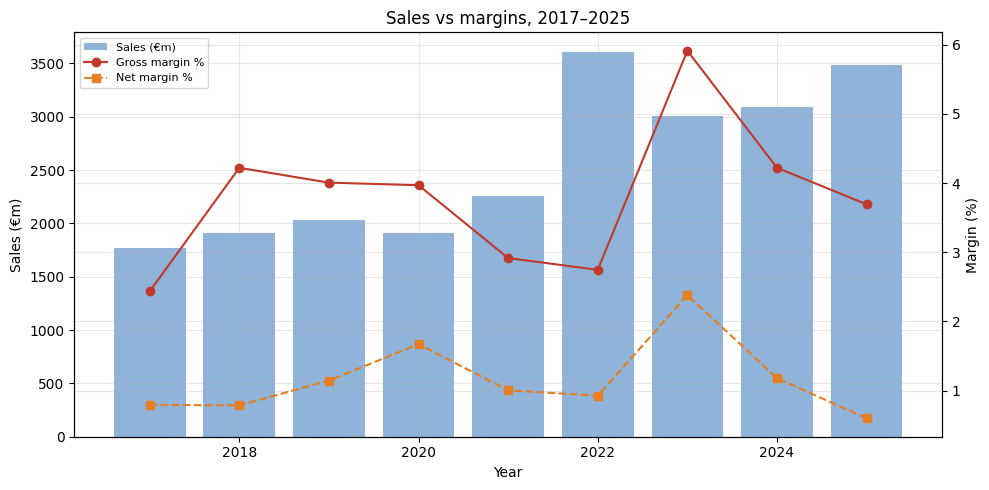

In [3]:
fig, ax1 = plt.subplots()
ax1.bar(wide.index, m("sales"), color="#8fb3d9", label="Sales (€m)")
ax1.set_ylabel("Sales (€m)"); ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(wide.index, gm, color="#c0392b", marker="o", label="Gross margin %")
ax2.plot(wide.index, nm, color="#e67e22", marker="s", linestyle="--", label="Net margin %")
ax2.set_ylabel("Margin (%)")

ax1.set_title("Sales vs margins, 2017–2025")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig(charts_dir / "01_sales_vs_margin.png", dpi=120, bbox_inches="tight")
plt.show()

### Result

Sales nearly doubled (€1.77bn → €3.48bn) while gross margin stayed in a thin, volatile 2.4%–5.9% band. Two things stand out: **2022** — sales peaked at €3.6bn but margin *fell* to 2.75%, a classic high-price/thin-spread trading year; and **2023** — margin spiked to 5.91% and net margin to a nine-year high, even though sales fell. The margin doesn't move with volume; it moves with how well the book was positioned against price. That is the essence of a trading business, and it's why Business Control exists — to protect a spread that a good or bad year can double or halve.

## B — Growth decomposition: volume vs price

For a trader, revenue growth splits into **volume** (tonnes moved) and **price/mix** (revenue per tonne). Because sales are stored in €'000 and volume in kt (MT '000), `sales / volume` gives revenue per tonne (€/t) directly.

In [4]:
rev_per_tonne = wide["sales"] / wide["volume_mt"]   # €/tonne

growth = pd.DataFrame({
    "sales_eur_m": m("sales").round(0),
    "volume_kt": wide["volume_mt"].round(0),
    "rev_per_tonne_eur": rev_per_tonne.round(0),
    "sales_growth_pct": (100 * wide["sales"].pct_change()).round(1),
    "volume_growth_pct": (100 * wide["volume_mt"].pct_change()).round(1),
})
growth

,sales_eur_m,volume_kt,rev_per_tonne_eur,sales_growth_pct,volume_growth_pct
year,,,,,
2017,1767.0,913.0,1935.0,NaN,NaN
2018,1910.0,1049.0,1820.0,8.1,14.9
2019,2029.0,1012.0,2005.0,6.3,-3.5
2020,1910.0,939.0,2034.0,-5.9,-7.2
2021,2253.0,1008.0,2236.0,18.0,7.3
2022,3610.0,1172.0,3080.0,60.2,16.3
2023,3005.0,1156.0,2599.0,-16.8,-1.4
2024,3086.0,1111.0,2778.0,2.7,-3.9
2025,3480.0,1181.0,2947.0,12.7,6.3


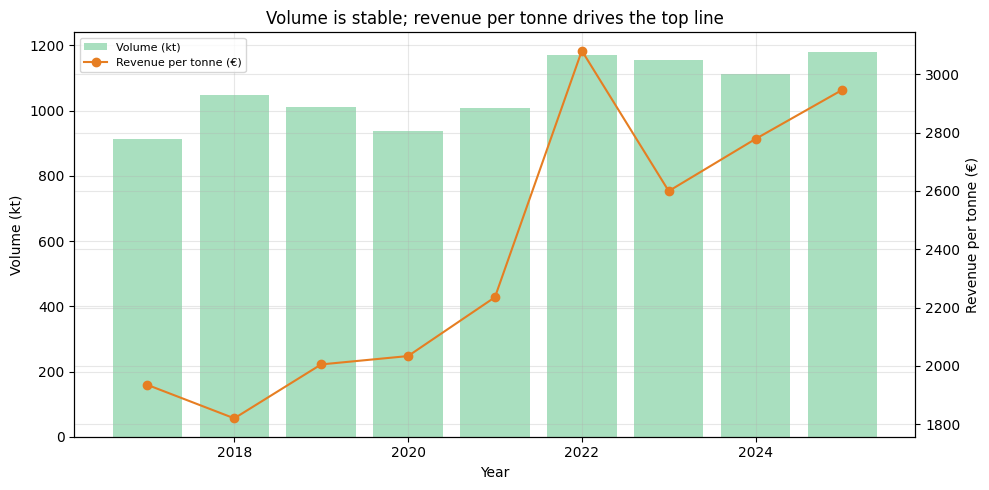

In [5]:
fig, ax1 = plt.subplots()
ax1.bar(wide.index, wide["volume_mt"], color="#a9dfbf", label="Volume (kt)")
ax1.set_ylabel("Volume (kt)"); ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(wide.index, rev_per_tonne, color="#e67e22", marker="o", label="Revenue per tonne (€)")
ax2.set_ylabel("Revenue per tonne (€)")

ax1.set_title("Volume is stable; revenue per tonne drives the top line")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig(charts_dir / "02_volume_vs_price.png", dpi=120, bbox_inches="tight")
plt.show()

### Result

Volume is remarkably stable (roughly 940–1,180 kt), while revenue per tonne swings hard — from ~€2,235/t (2021) to ~€3,080/t (2022) and back. So Interfood's revenue growth is **price-driven, not volume-driven**: the €1.4bn jump in 2022 sales came almost entirely from dairy prices spiking (post-COVID demand + the Russia/Ukraine shock), not from moving materially more product. This is the single most important thing to understand about reading a dairy trader's top line — a "record revenue year" can simply mean high prices, and says little about how well the business actually traded. Margin, not revenue, is the real scoreboard.

## C — Working-capital intensity

A trader ties up cash in inventory and receivables. We measure net working capital both in absolute terms and as a % of sales, to see how capital-hungry the business is and whether that's worsening.

In [6]:
nwc_intensity = 100 * wide["net_working_capital"] / wide["sales"]

wc = pd.DataFrame({
    "nwc_eur_m": m("net_working_capital").round(0),
    "nwc_pct_of_sales": nwc_intensity.round(1),
})
wc

,nwc_eur_m,nwc_pct_of_sales
year,,
2017,77.0,4.4
2018,92.0,4.8
2019,113.0,5.6
2020,128.0,6.7
2021,137.0,6.1
2022,167.0,4.6
2023,200.0,6.7
2024,209.0,6.8
2025,213.0,6.1


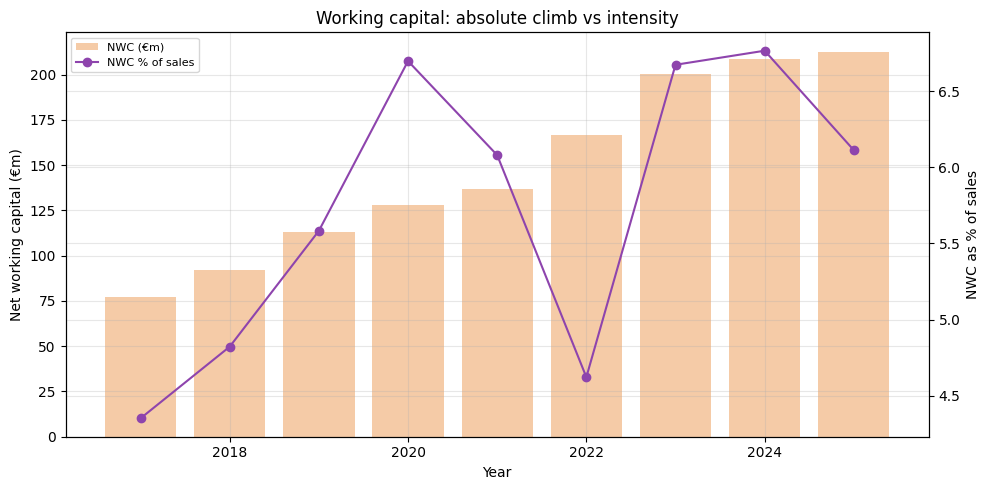

In [7]:
fig, ax1 = plt.subplots()
ax1.bar(wide.index, m("net_working_capital"), color="#f5cba7", label="NWC (€m)")
ax1.set_ylabel("Net working capital (€m)"); ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(wide.index, nwc_intensity, color="#8e44ad", marker="o", label="NWC % of sales")
ax2.set_ylabel("NWC as % of sales")

ax1.set_title("Working capital: absolute climb vs intensity")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig(charts_dir / "03_working_capital.png", dpi=120, bbox_inches="tight")
plt.show()

### Result

Net working capital climbed relentlessly: €76.9m (2017) → €212.7m (2025), nearly tripling. As a share of sales it's held roughly 4–7% — but the *absolute* capital base keeps growing as the business scales. This is why a metric that charges for capital (their EPR) matters so much: on a thin margin, every extra euro tied up in inventory and receivables is a real cost. Working-capital discipline isn't housekeeping here — it's central to whether the business creates value.

## D — Profit vs cash

Accounting profit and cash generation diverge sharply for a trader, because working-capital swings dominate cash flow. We compare net result to operating cash flow directly.

**Caveat:** as of 2023, Interfood reclassified borrowings out of financing cash flow, so the operating-cash-flow series has a methodology break — pre- and post-2023 figures aren't strictly comparable.

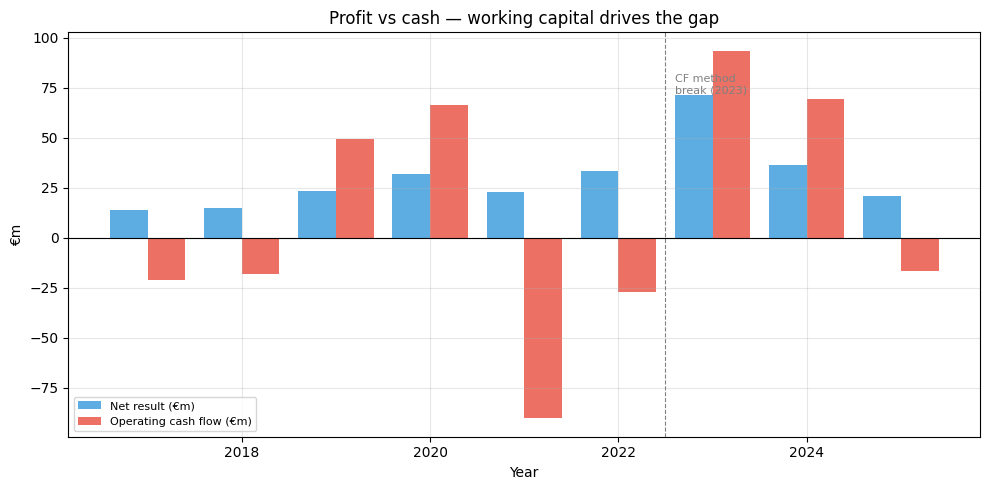

In [8]:
x = wide.index.astype(int)
w = 0.4
fig, ax = plt.subplots()
ax.bar(x - w/2, m("net_result"), width=w, color="#5dade2", label="Net result (€m)")
ax.bar(x + w/2, m("operating_cash_flow"), width=w, color="#ec7063", label="Operating cash flow (€m)")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(2022.5, color="gray", linestyle="--", linewidth=0.8)
ax.text(2022.6, ax.get_ylim()[1]*0.7, "CF method\nbreak (2023)", fontsize=8, color="gray")
ax.set_ylabel("€m"); ax.set_xlabel("Year")
ax.set_title("Profit vs cash — working capital drives the gap")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
plt.savefig(charts_dir / "04_profit_vs_cash.png", dpi=120, bbox_inches="tight")
plt.show()

### Result

The divergence is stark. In **2021**, Interfood earned €22.6m of profit but *consumed* €90.4m of operating cash — a record year that drained cash because working capital ballooned as prices rose. The pattern repeats: strong-profit, high-price years (2021) tend to be cash-negative, while price-normalising years (2023) release cash. For a trader, **profit and cash can move in opposite directions**, and the driver is working capital. A controller who only watches the P&L misses half the picture — which is exactly why cash and working-capital monitoring sit in the role.

## E — Balance-sheet health: solvency, liquidity, leverage

Because the business is capital-hungry and bank-financed (a secured borrowing-base facility), solvency and liquidity ratios matter — they underpin the borrowing capacity the trading operation runs on.

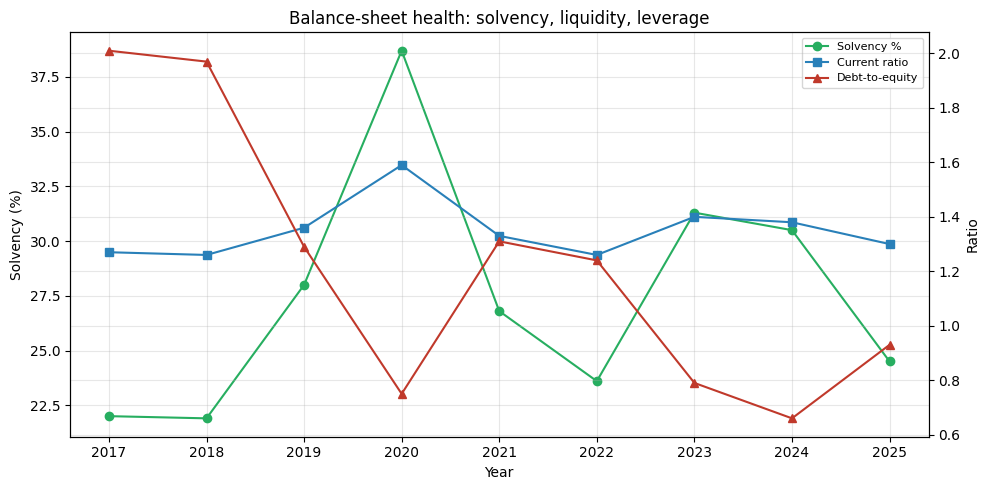

In [9]:
fig, ax1 = plt.subplots()
ax1.plot(wide.index, wide["solvency_pct"], marker="o", color="#27ae60", label="Solvency %")
ax1.set_ylabel("Solvency (%)"); ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(wide.index, wide["current_ratio"], marker="s", color="#2980b9", label="Current ratio")
ax2.plot(wide.index, wide["debt_to_equity"], marker="^", color="#c0392b", label="Debt-to-equity")
ax2.set_ylabel("Ratio")

ax1.set_title("Balance-sheet health: solvency, liquidity, leverage")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper right", fontsize=8)
fig.tight_layout()
plt.savefig(charts_dir / "05_balance_sheet_health.png", dpi=120, bbox_inches="tight")
plt.show()

### Result

Solvency has moved between ~22% and ~39%, sitting at 24.5% in 2025 — down from 30.5% in 2024 as the balance sheet grew on higher working capital. The current ratio stays comfortably above 1 (1.3 in 2025), and leverage (debt-to-equity) has generally eased. The picture is a business that stays adequately capitalised but runs a *tightening* solvency ratio as it scales — consistent with a borrowing-base model where growth consumes balance-sheet headroom. Not a red flag, but the direction is worth watching, and it's why capital discipline is a live management concern.

## F — Summary scorecard

One table pulling the key metrics together, transposed for a clean year-by-year read.

In [10]:
summary = pd.DataFrame({
    "Sales (€m)": m("sales").round(0),
    "Gross margin %": gm.round(2),
    "Net margin %": nm.round(2),
    "Rev per tonne (€)": rev_per_tonne.round(0),
    "NWC (€m)": m("net_working_capital").round(0),
    "NWC % sales": nwc_intensity.round(1),
    "Op cash flow (€m)": m("operating_cash_flow").round(0),
    "Solvency %": wide["solvency_pct"],
    "Current ratio": wide["current_ratio"],
    "CCC (days)": wide["cash_conversion_cycle"],
})
summary.T

year,2017,2018,2019,2020,2021,2022,2023,2024,2025
Sales (€m),1767.00,1910.00,2029.00,1910.00,2253.00,3610.00,3005.00,3086.00,3480.00
Gross margin %,2.43,4.22,4.01,3.97,2.92,2.75,5.91,4.22,3.69
Net margin %,0.79,0.79,1.14,1.67,1.00,0.93,2.38,1.18,0.60
Rev per tonne (€),1935.00,1820.00,2005.00,2034.00,2236.00,3080.00,2599.00,2778.00,2947.00
NWC (€m),77.00,92.00,113.00,128.00,137.00,167.00,200.00,209.00,213.00
NWC % sales,4.40,4.80,5.60,6.70,6.10,4.60,6.70,6.80,6.10
Op cash flow (€m),-21.00,-18.00,49.00,66.00,-90.00,-27.00,94.00,69.00,-16.00
Solvency %,22.00,21.90,28.00,38.70,26.80,23.60,31.30,30.50,24.50
Current ratio,1.27,1.26,1.36,1.59,1.33,1.26,1.40,1.38,1.30
CCC (days),53.10,53.80,52.50,49.60,50.30,42.50,43.50,46.20,46.60


## Conclusion — what the numbers say

**The business in six findings (the interview-ready read):**

1. **High volume, thin margin.** Sales doubled to €3.48bn (2025) on gross margins of just 2.4%–5.9%. This is a low-margin, high-turnover trading model — protecting the spread is everything.

2. **Revenue is price-driven, not volume-driven.** Volume is stable (~940–1,180 kt); revenue swings come from dairy prices (revenue/tonne ranged ~€2,235–€3,080). A "record revenue year" often just means high prices, not better trading.

3. **Margin is the real scoreboard, and it's volatile.** 2023's margin (5.9%) was more than double 2022's (2.75%) — driven by positioning against price, not volume. This is precisely the volatility a Business Control function exists to manage.

4. **The business is capital-hungry and getting more so.** Net working capital nearly tripled (€76.9m → €212.7m). On a thin margin, that capital has a real cost — the reason Interfood judges itself on economic profit (EPR), not just P&L.

5. **Profit and cash diverge.** 2021 earned €22.6m of profit but consumed €90.4m of operating cash. Working capital, not profit, drives cash — so a controller must watch both.

6. **Solvency is tightening as it scales.** Down to 24.5% (2025) from 30.5% (2024) as the balance sheet grew — adequately capitalised, but the borrowing-base model means growth consumes headroom.

**What's next:**
- **`04_credit_risk_analysis.ipynb`** — model the P&L/EPR impact of a counterparty default (generalising the E-Piim write-off), the highest-relevance module for the role.
- The 2023 margin spike and the EPR series are the two things still worth enriching from the report narrative.